# SWIGGY SALES ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Import Data

In [2]:
df=pd.read_excel("B:\projects\Swiggy Sals Analysis\swiggy_data.xlsx")
df

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
...,...,...,...,...,...,...,...,...,...,...
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0


In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


## Meta Data

In [5]:
print("No of Rows:",df.shape[0])

No of Rows: 197430


In [6]:
df.loc[1,"City"]

'Bengaluru'

In [7]:
print("No of Fields:",df.shape[1])

No of Fields: 10


In [8]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

## Data Types

In [9]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [10]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [11]:
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# KPI's

### Total Sales

In [12]:
total_sales=df['Price (INR)'].sum()
print('Totals Sales (INR):', round(total_sales,2))

Totals Sales (INR): 53012505.77


### Average Rating

In [13]:
average_rating=df['Rating'].mean()
print('Average Rating:', round(average_rating,1))

Average Rating: 4.3


### Average Order Value

In [14]:
avg_order_Value=df['Price (INR)'].mean()
print('Avg Order Value (INR):', round(avg_order_Value,2))

Avg Order Value (INR): 268.51


### Rating Count

In [15]:
rating_count=df['Rating Count'].sum()
print('Rating Count:', round(rating_count,2))

Rating Count: 5591574


### Total Orders

In [16]:
Total_Order=df['State'].count()
print('Total Order:', round(Total_Order,2))

Total Order: 197430


# CHART DESIGN

### Monthly Sales Trend

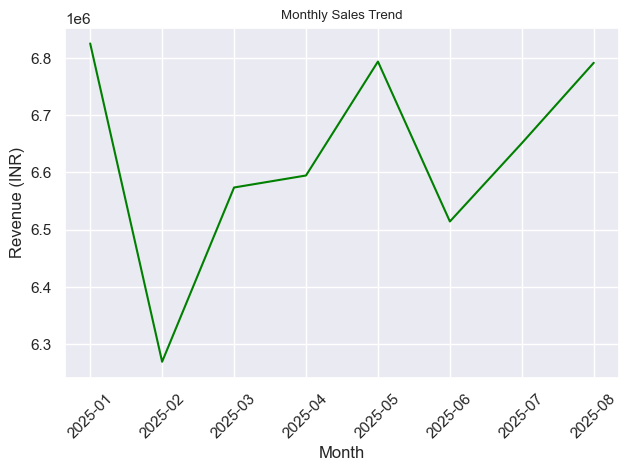

In [190]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['YearMonth']=df["Order Date"].dt.to_period("M").astype(str)
monthly_revenue=df.groupby('YearMonth')['Price (INR)'].sum().reset_index()

plt.figure()
sns.lineplot(x='YearMonth',y='Price (INR)',data=monthly_revenue,color='green')
plt.xticks(rotation=45)
sns.set_theme(style="darkgrid")
sns.set_context("paper")
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.show()

### Daily Sales Trend

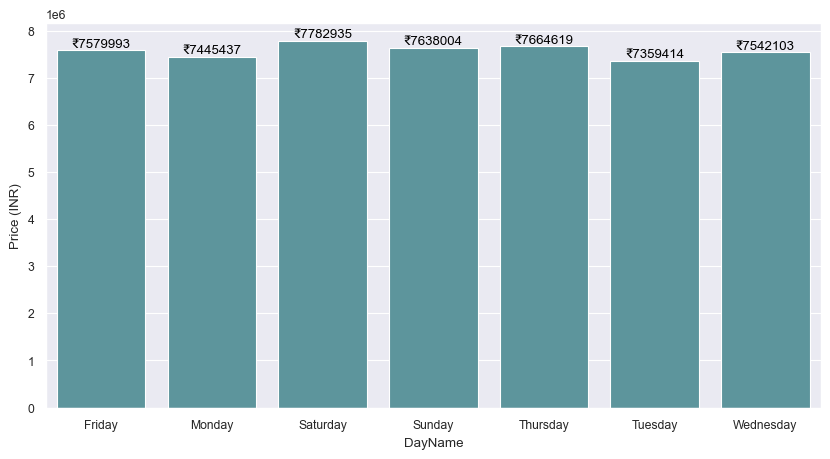

In [192]:
df.columns = df.columns.str.strip()
df['DayName']=pd.to_datetime(df['Order Date']).dt.day_name()
daily_revenue=df.groupby("DayName")["Price (INR)"].sum().reset_index()

plt.figure(figsize=(10,5))
ax=sns.barplot(x='DayName',y='Price (INR)',data=daily_revenue,color='#539DA6')
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0],fmt="₹%.0f",label_type="edge",color="black")

plt.show()

### Total Sales by Food Type (Veg vs Non-Veg)

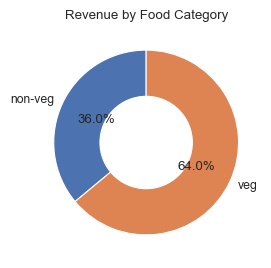

In [19]:
non_veg_dish = {"egg","chicken","mutton","prawn","biryani","kabab","non-veg","non veg"}

df["Food_Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_dish), na=False),
    "non-veg",
    "veg"
)

df["Food_Category"] = df["Food_Category"].astype(str)

salesbyfoodtype = (
    df.groupby("Food_Category")["Price (INR)"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(4,3))

plt.pie(
    salesbyfoodtype["Price (INR)"],
    labels=salesbyfoodtype["Food_Category"],
    autopct="%1.1f%%",
    startangle=90
)

# Create center circle (donut hole)
centre_circle = plt.Circle((0,0),0.50,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Revenue by Food Category")

plt.show()

### Total Sales by State


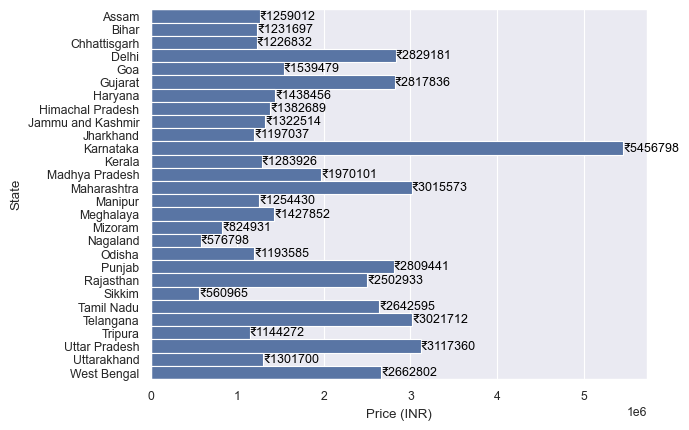

<Figure size 3000x1500 with 0 Axes>

In [20]:
state=df.groupby('State')['Price (INR)'].sum().reset_index()
ax=sns.barplot(x="Price (INR)",y="State",data=state,width=1)
sns.set_theme(style="darkgrid", palette="deep")
sns.set_context("paper")

plt.figure(figsize=(30,15))

ax.bar_label(ax.containers[0],fmt="₹%.0f",label_type="edge",color="black")
for t in ax.texts:
    t.set(fontsize=9)
plt.show()

### Quarterly Performance Summary

In [21]:
df['quarter'] = df['Order Date'].dt.to_period('Q')

quaters = df.groupby("quarter").agg(
    revenue=("Price (INR)", "sum"),
    avg_order=("Rating", "mean"),
    total_orders=("Order Date", "count")
)
quaters

,revenue,avg_order,total_orders
quarter,,,
2025Q1,19667821.77,4.342643,73096
2025Q2,19902256.59,4.340011,74163
2025Q3,13442427.41,4.342359,50171


### Top 5 Cities by Sales

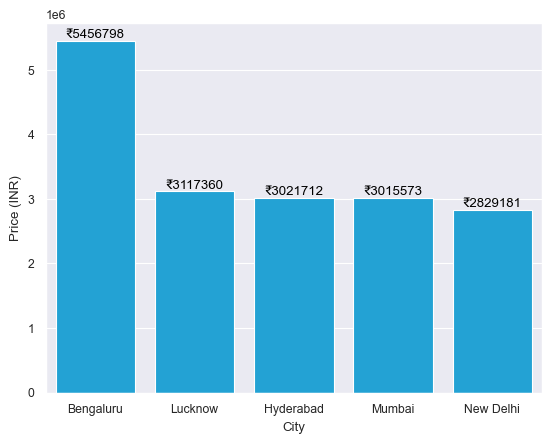

In [188]:
top5 = df.groupby('City')['Price (INR)'].sum().nlargest(5).reset_index()

ax=sns.barplot(x="City", y="Price (INR)", data=top5,color='#05AFF2')
sns.set_theme(style="darkgrid", palette="Set1")
sns.set_context("paper")

ax.bar_label(ax.containers[0],fmt="₹%.0f",label_type="edge")
for t in ax.texts:
    t.set(color='black')
plt.show()

### Sales for Particular Month

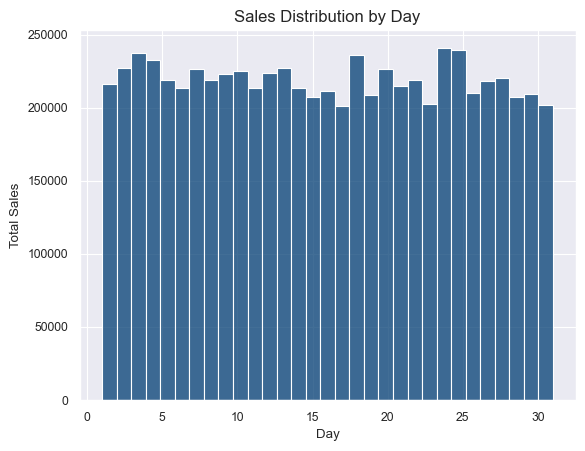

In [189]:
filtered = df[
    (df['Order Date'].dt.year == 2025) &
    (df['Order Date'].dt.month == 8)
]
group=df.groupby(filtered['Order Date'].dt.day)['Price (INR)'].sum().reset_index()
sns.histplot(
    x=group['Order Date'],
    weights=group['Price (INR)'],  
    bins=31,
    color="#023E73"
)
sns.set_theme(style="darkgrid")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.title("Sales Distribution by Day")

plt.show()

### Top Rating Dish Name

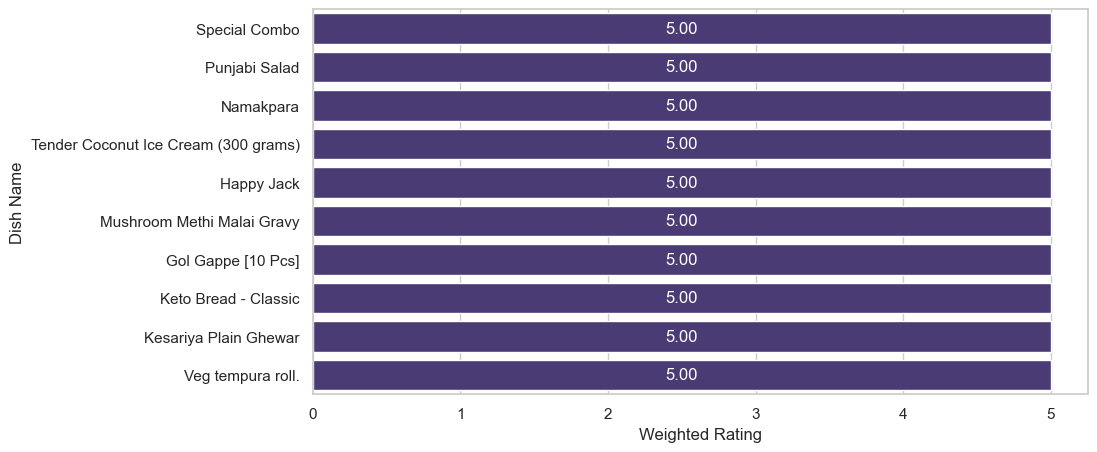

In [108]:
dish_df = (
    df.assign(weighted=df["Rating"] * df["Rating Count"])
    .groupby("Dish Name", as_index=False)
    .agg({
        "weighted": "sum",
        "Rating Count": "sum"
    })
)

dish_df.rename(columns={"Rating Count": "Total Count"}, inplace=True)

dish_df["Weighted Rating"] = (
    dish_df["weighted"] / dish_df["Total Count"]
)

top10 = dish_df.sort_values(
    by=["Weighted Rating", "Total Count"],
    ascending=False
).head(10)

sns.set_theme(style="whitegrid", palette="viridis")

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x="Weighted Rating",
    y="Dish Name",
    data=top10
)

ax.bar_label(ax.containers[0], fmt="%.2f", label_type="center",color='white')
plt.show()

### The Dish Name Which Consecutive selling Three Days

In [39]:
df.sort_values(["Dish Name", "Order Date"])
df["prev_date"] = df.groupby("Dish Name")["Order Date"].shift(1)
df["diff"] = (df["Order Date"] - df["prev_date"]).dt.days
df["new_group"] = (df["diff"] != 1).astype(int)
df["streak_group"] = df.groupby("Dish Name")["new_group"].cumsum()
streaks = (
    df.groupby(["Dish Name", "streak_group"])
    .size()
    .reset_index(name="streak_days")
)
result = streaks[streaks["streak_days"] >= 3]
result

,Dish Name,streak_group,streak_days
101562,Kitkat Baked Cheesecake Jar,7,3
138673,Paneer Chilli,18,3


### Price vs Rating Analysis

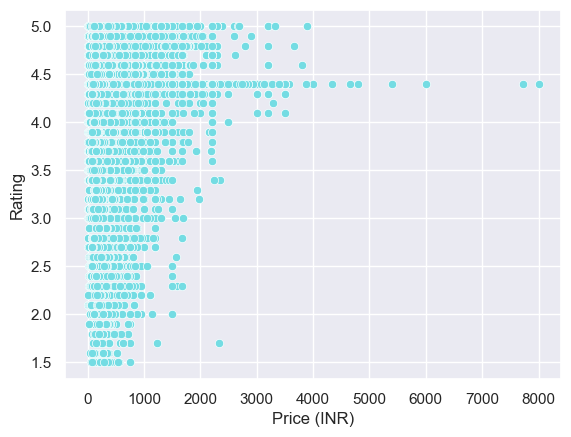

In [145]:
sns.scatterplot(data=df,y="Rating",x='Price (INR)',color="#74DCE3")
sns.set_theme(style="darkgrid")
plt.show()

### Price vs Rating Count Analysis

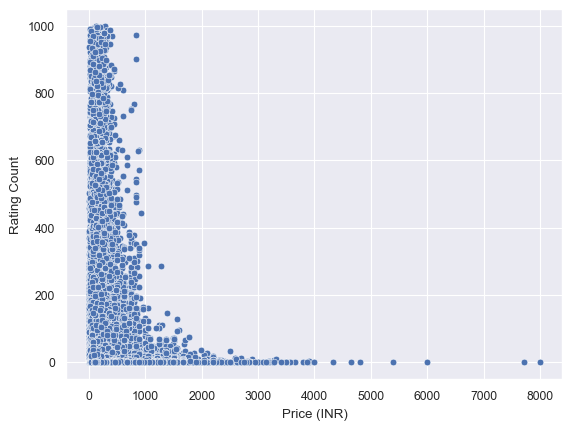

In [193]:
sns.scatterplot(x="Price (INR)", y="Rating Count", data=df)
plt.show()

### Top 10 Restaurant by Total Sales

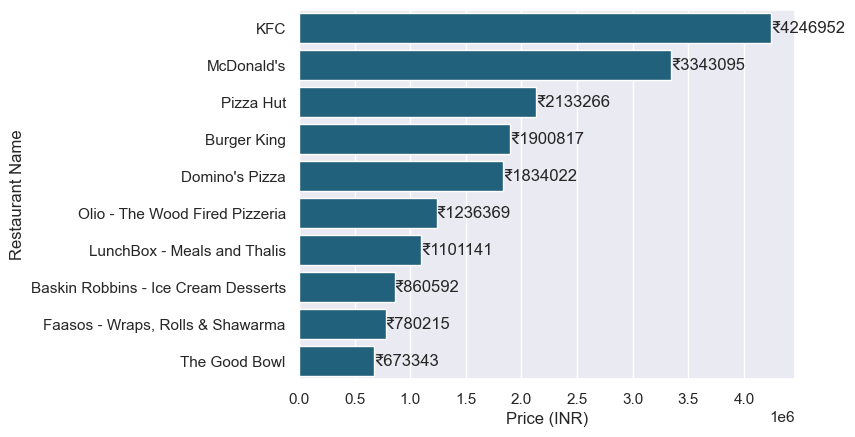

<Figure size 3000x1500 with 0 Axes>

In [141]:
top10cat=df.groupby('Restaurant Name')['Price (INR)'].sum().sort_values(ascending=False).head(10).reset_index()
ax=sns.barplot(y='Restaurant Name',x='Price (INR)',data=top10cat,color="#13678A")
plt.figure(figsize=(30,15))
sns.set_theme(style="darkgrid",palette='deep')
ax.bar_label(ax.containers[0], fmt="₹%.0f", label_type="edge")
plt.show()

### Total by Food Category

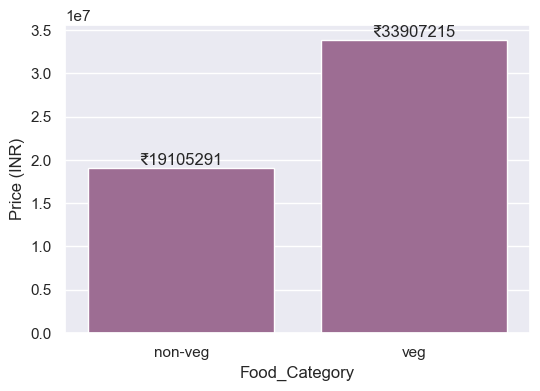

In [181]:
food_rev = df.groupby('Food_Category')['Price (INR)'].sum().reset_index()

plt.figure(figsize=(6,4))
colors=['#a56597','#a56597']
ax = sns.barplot(
    data=food_rev,
    x='Food_Category',
    y='Price (INR)',
    color='#a56597',
    legend=False
)

# Show value on top
ax.bar_label(ax.containers[0], fmt="₹%.0f", label_type='edge')

plt.show()

### Rating

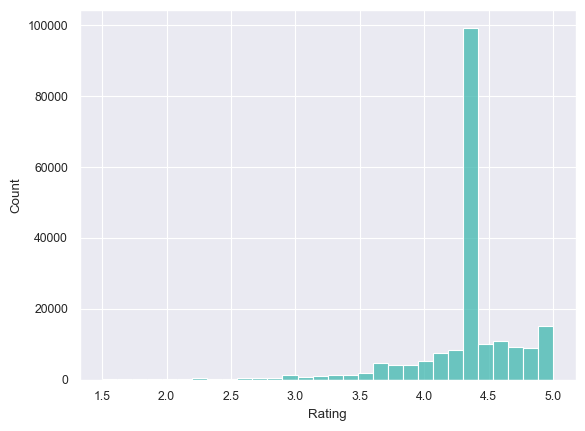

In [187]:
sns.histplot(df['Rating'],bins=30,color="#3FB8AF")
plt.show()

In [ ]:
### 

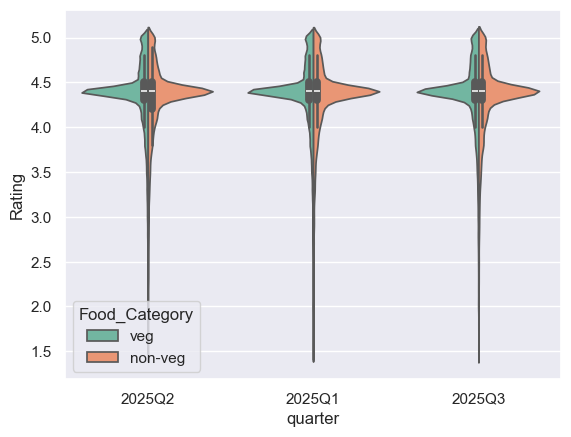

In [102]:
sns.violinplot(data=df, x='quarter', y='Rating',hue='Food_Category',split=True)
plt.show()